In [2]:
using IonSim
using QuantumOptics
using PyPlot
using LinearAlgebra

In [3]:
function plot_wigner(final_state)
    rho_motional = ptrace(final_state, 1)

b_fock = FockBasis(10)
rho_fock = DenseOperator(b_fock, rho_motional.data)

x_vec = -4.0:0.1:4.0
p_vec = -4.0:0.1:4.0

W = wigner(rho_fock, x_vec, p_vec)

fig = figure(figsize=(8, 6))
PyPlot.pcolormesh(x_vec, p_vec, W, cmap="RdBu_r", vmin=-0.1, vmax=0.3, shading="nearest")
PyPlot.colorbar(label="Wigner Function W(x, p)")

# Add a marker where the vacuum state (0,0) originally was
PyPlot.plot([0], [0], "w+", markersize=15, markeredgewidth=2, label="Original Vacuum |0>")

PyPlot.xlabel("Position (x)")
PyPlot.ylabel("Momentum (p)")
PyPlot.title("Displaced Motional State")
PyPlot.legend()
PyPlot.grid(color="white", alpha=0.2)

# Display the figure safely in Jupyter (removed show() to prevent the device warning)
display(fig)
end


plot_wigner (generic function with 1 method)

In [4]:
function calculate_qcrb(state, state_perturbed, d_alpha::Float64; tol=1e-10)
    
    # 1. Promote pure states (Ket) to density matrices
    rho1 = isa(state, Ket) ? dm(state) : state
    rho2 = isa(state_perturbed, Ket) ? dm(state_perturbed) : state_perturbed
    
    # 2. Extract dense data
    rho_dense_data = dense(rho1).data
    rho_pert_dense_data = dense(rho2).data

    # 3. Finite difference derivative
    drho_data = (rho_pert_dense_data - rho_dense_data) / d_alpha
    
    # 4. Use Hermitian() to guarantee real eigenvalues and speed up diagonalization
    λ, V = LinearAlgebra.eigen(Hermitian(rho_dense_data))
    
    qfi = 0.0
    n = length(λ)
    
    for i in 1:n
        for j in 1:n
            if real(λ[i] + λ[j]) > tol
                # 5. Use @views to prevent memory allocation during column slicing
                @views v_i = V[:, i]
                @views v_j = V[:, j]
                
                drho_ij = dot(v_i, drho_data * v_j)
                qfi += 2 * (abs(drho_ij)^2) / real(λ[i] + λ[j])
            end
        end
    end
    
    qcrb = qfi > 0 ? 1.0 / qfi : Inf
    return qfi, qcrb
end

calculate_qcrb (generic function with 1 method)

In [5]:
angle = 0
target_alpha = 0.716
cat_state = false
initial_state = nothing

red_angle = (π - 2*angle ) /2
blue_angle = red_angle + 2 *angle

if (cat_state)
    println("Preparing cat state superposition...")
    red_angle = -angle
    blue_angle = angle
end

trap_freq = 19e5 # 1.9 MHz trap frequency
ion = Ca40([("S1/2", -1/2, "g"), ("D5/2", -5/2, "e")])
chain = LinearChain(ions=[ion], comfrequencies=(x=3e6, y=3e6, z=trap_freq), selectedmodes=(; z=[1]))

mode_z = zmodes(chain)[1] # Get the first (and only) Z-mode of the chain
mode_z.N = 10

k_vec = (x̂ + ẑ) / √2
ϵ_vec = ŷ

laser_intensity = 1e4 # Fixed intensity
B_field = 1e-13

# Pre-build a trap just to grab the transition wavelength
trap_pre = Chamber(iontrap=chain, B=B_field, Bhat=ẑ)
transition_λ = transitionwavelength(ion, ("g", "e"), trap_pre)

# ---------------------------------------------------------
# NEW: DYNAMIC TIME CALCULATION VIA WIGNER-ECKART ENGINE
# ---------------------------------------------------------
hbar = 1.0545718e-34       
amu = 1.66053906e-27       
m_Ca40 = 39.96259 * amu    
c = 2.99792458e8           

# 1. Calculate Lamb-Dicke Parameter (η) dynamically
omega_trap = 2 * π * trap_freq
z_zpf = sqrt(hbar / (2 * m_Ca40 * omega_trap))
k_total = 2 * π / transition_λ
k_z = k_total / sqrt(2)
eta = k_z * z_zpf

# 2. Hijack IonSim's internal matrix element calculator
dummy_laser = Laser(I=laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)
Bhat_tuple = (; x=0.0, y=0.0, z=1.0)

# Feed the dummy laser into the exact internal physics engine
# (Note: Unexported internal functions need the module prefix 'IonSim.')
Omega_eff_Hz = IonSim.matrixelement(ion, ("g", "e"), laser_intensity, polarization(dummy_laser), wavevector(dummy_laser), Bhat_tuple)
Omega_eff = Omega_eff_Hz * 2 * π
# 3. Solve the displacemen formula backward to find exactly how long to leave the lasers on
target_time_s = (2 * target_alpha) / (eta * Omega_eff)
target_time_us = target_time_s * 1e6
# ---------------------------------------------------------

# Now build the actual lasers and final chamber
L_red = Laser(Δ = -trap_freq, ϕ=red_angle, I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)
L_blue = Laser(Δ = trap_freq, ϕ=blue_angle, I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)

trap = Chamber(iontrap=chain, B=B_field, Bhat=ẑ, lasers=[L_red, L_blue])

mode = zmodes(trap)[1]
println(mode)

ψ_ion = normalize(ion["g"] - ion["e"])
ψ_mode = fockstate(mode, 0)
ψ_initial = ψ_ion ⊗ ψ_mode

if (initial_state != nothing)
    println("Using provided initial state...")
    ψ_initial = initial_state
end

h = hamiltonian(trap, timescale=1e-6, rwa_cutoff=Inf)

# Ensure our solver array steps exactly up to our calculated target time
tspan_array = collect(0:0.5:target_time_us)
if tspan_array[end] < target_time_us
    push!(tspan_array, target_time_us)
end

println("\n--- DYNAMIC DISPLACEMENT SETUP ---")
println("Target Magnitude (|α|) : ", target_alpha)
println("Fixed Laser Intensity  : ", laser_intensity, " W/m²")
println("True Engine Ω_eff      : ", round(Omega_eff, digits=2), " rad/s")
println("Calculated Time (t)    : ", round(target_time_us, digits=3), " μs")
println("----------------------------------\n")

println("Simulating bichromatic displacement...")
tout, sol = timeevolution.schroedinger_dynamic(tspan_array, ψ_initial, h)

final_state = sol[end]

# ---------------------------------------------------------
# VERIFICATION PRINT BLOCK
# ---------------------------------------------------------
println("\n--- VERIFYING DISPLACEMENT PARAMETERS ---")
println("Zero-Point Fluctuation (z_zpf) : ", round(z_zpf * 1e9, digits=4), " nm")
println("Z-Projected Wavevector (k_z)   : ", round(k_z, digits=2), " m⁻¹")
println("Lamb-Dicke Parameter (η)       : ", round(eta, digits=4))

# We no longer calculate geometric_factor manually. We pull Ω_eff directly from the engine!
println("Effective Rabi Freq (Ω_eff)    : ", Omega_eff, " rad/s")

# |α| = 1/2 * η * Ω_eff * t 
alpha_mag = 0.5 * eta * Omega_eff * target_time_s 

println("-----------------------------------------")
println("FINAL DISPLACEMENT MAGNITUDE (|α| = 0.5 * η * Ω_eff * t) : ", round(alpha_mag, digits=3), " (Targeted: $target_alpha)")
println("-----------------------------------------")

VibrationalMode(ν=1.9e6, axis=ẑ, N=10)

--- DYNAMIC DISPLACEMENT SETUP ---
Target Magnitude (|α|) : 0.716
Fixed Laser Intensity  : 10000.0 W/m²
True Engine Ω_eff      : 57655.0 rad/s
Calculated Time (t)    : 499.633 μs
----------------------------------

Simulating bichromatic displacement...

--- VERIFYING DISPLACEMENT PARAMETERS ---
Zero-Point Fluctuation (z_zpf) : 8.1584 nm
Z-Projected Wavevector (k_z)   : 6.09326094e6 m⁻¹
Lamb-Dicke Parameter (η)       : 0.0497
Effective Rabi Freq (Ω_eff)    : 57654.99800388868 rad/s
-----------------------------------------
FINAL DISPLACEMENT MAGNITUDE (|α| = 0.5 * η * Ω_eff * t) : 0.716 (Targeted: 0.716)
-----------------------------------------


Ket(dim=22)
  basis: [⁴⁰Ca ⊗ VibrationalMode(ν=1.9e6, axis=ẑ, N=10)]
   0.5450724734244152 + 1.404863281754e-5im
  -0.5500630133083152 - 1.366575032934e-5im
   -5.423294328424e-5 + 0.38992256197509145im
    5.364898271983e-5 - 0.39348372055944586im
 -0.19699261794464973 - 5.015637022388e-5im
  0.19878811173438476 + 4.970955984706e-5im
    3.021923572959e-5 - 0.08115997289155563im
    -2.99744485765e-5 + 0.08189715939831442im
  0.02892162654602662 + 1.423757847265e-5im
 -0.02918404454742192 - 1.412949519357e-5im
     -5.6569585365e-6 + 0.00920699369077326im
     5.61607311065e-6 - 0.00929016395677515im
 -0.00267224591268955 - 1.97416345587e-6im
  0.00269638276178352 + 1.96050688565e-6im
      6.2058622637e-7 - 0.00071718795632772im
     -6.1644583554e-7 + 0.00072363098620465im
  0.00017983715843319 + 1.7873859289e-7im
 -0.00018145417018695 - 1.7758980745e-7im
      -4.784872924e-8 + 4.237047749384e-5im
       4.754938748e-8 - 4.274901408237e-5im
    -9.93723672006e-6 - 1.158922325e-8im

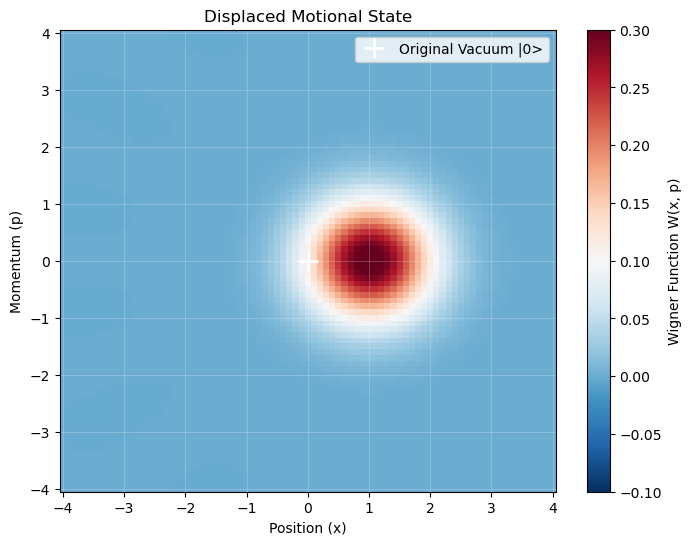

In [6]:
println(final_state)
plot_wigner(final_state)



In [7]:
# Example loop for Protocol 1 Finite Difference
t_base = 10.0
dt = 0.001
t_perturbed = t_base + dt

# Run simulation to t_base
tout1, sol1 = timeevolution.schroedinger_dynamic([0.0, t_base], ψ_initial, h)
state_base = sol1[end] # This is a Ket

# Run simulation to t_perturbed
tout2, sol2 = timeevolution.schroedinger_dynamic([0.0, t_perturbed], ψ_initial, h)
state_perturbed = sol2[end] # This is a Ket

# Calculate QCRB! 
# The function will now automatically convert your Kets to DenseOperators.
qfi, qcrb = calculate_qcrb(state_base, state_perturbed, dt)

println("Quantum Fisher Information: ", qfi)
println("Quantum Cramér-Rao Bound: ", qcrb)

Quantum Fisher Information: 0.013295709890860655
Quantum Cramér-Rao Bound: 75.21223072770191


In [8]:
# Example loop for Protocol 1 Finite Difference
t_base = 10.0
dt = 0.001
t_perturbed = t_base + dt

# Run simulation to t_base
tout1, sol1 = timeevolution.schroedinger_dynamic([0.0, t_base], ψ_initial, h)
state_base = ptrace(sol1[end], 1) # This is a Ket

# Run simulation to t_perturbed
tout2, sol2 = timeevolution.schroedinger_dynamic([0.0, t_perturbed], ψ_initial, h)
state_perturbed = ptrace(sol2[end], 1) # This is a Ket

# Calculate QCRB! 
# The function will now automatically convert your Kets to DenseOperators.
qfi, qcrb = calculate_qcrb(state_base, state_perturbed, dt)

println("Quantum Fisher Information: ", qfi)
println("Quantum Cramér-Rao Bound: ", qcrb)

Quantum Fisher Information: 3.277512040865139e-5
Quantum Cramér-Rao Bound: 30510.94816835632


In [9]:
println(state_base)

Operator(dim=11x11)
  basis: VibrationalMode(ν=1.9e6, axis=ẑ, N=10)
     0.999795+0.0im           -1.34814e-8-0.0143097im   -0.000144644+2.65287e-10im  3.38603e-12+1.1923e-6im      8.50089e-9-3.49e-14im      -3.1e-16-5.41442e-11im  -3.1442e-13+0.0im           0.0+1.69e-15im  1.0e-17-0.0im  -0.0-0.0im  -0.0+0.0im
  -1.34814e-8+0.0143097im      0.00020481+0.0im         -1.84655e-12-2.07023e-6im    -1.7065e-8+3.239e-14im         3.8e-16+1.2167e-10im  7.7495e-13-0.0im                 -0.0-4.5e-15im  -2.0e-17+0.0im           0.0+0.0im   0.0-0.0im  -0.0-0.0im
 -0.000144644-2.65287e-10im  -1.84655e-12+2.07023e-6im    2.09261e-8+0.0im             -1.7e-16-1.72494e-10im  -1.22985e-12+0.0im                0.0+7.83e-15im         5.0e-17-0.0im          -0.0-0.0im          -0.0+0.0im   0.0+0.0im   0.0-0.0im
  3.38603e-12-1.1923e-6im      -1.7065e-8-3.239e-14im       -1.7e-16+1.72494e-10im  1.42187e-12+0.0im                  -0.0-1.014e-14im     -6.0e-17+0.0im                  0.0+0.0im           0

Simulating Fock State |0⟩...
Simulating Fock State |1⟩...
Simulating Fock State |2⟩...
Simulating Fock State |3⟩...
Simulating Fock State |4⟩...
Simulating Fock State |5⟩...


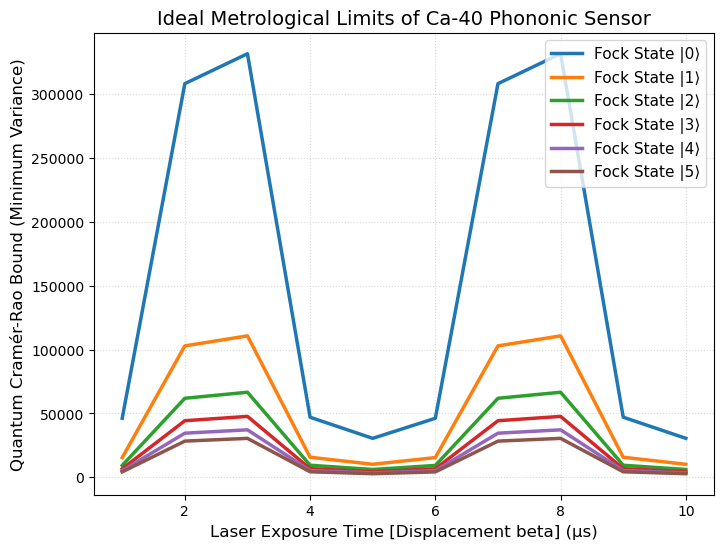

In [10]:
# Example loop to plot QCRB over time (displacement)
t_max = 10.0
dt = 0.001
time_steps = 1.0:1.0:t_max # Use explicit floats for the time span

states = 0:5 # Test Fock states |0> through |5>

fig = figure(figsize=(8, 6))

# Safely pre-allocate a 2D matrix of zeros
# Rows = number of Fock states, Columns = number of time steps
qcrb_matrix = zeros(Float64, length(states), length(time_steps))

for (i, n) in enumerate(states)
    qcrb_values = Float64[]
    
    # Initialize state
    ψ_mode = fockstate(mode, n)
    ψ_initial = ψ_ion ⊗ ψ_mode
    
    println("Simulating Fock State |", n, "⟩...")
    
    for (j, t) in enumerate(time_steps)
        # Run simulation to current time t
        tout1, sol1 = timeevolution.schroedinger_dynamic([0.0, t], ψ_initial, h)
        state_base = ptrace(sol1[end], 1) 
        
        # Run simulation to slightly perturbed time t + dt
        tout2, sol2 = timeevolution.schroedinger_dynamic([0.0, t + dt], ψ_initial, h)
        state_perturbed = ptrace(sol2[end], 1) 
        
        # Calculate QCRB
        qfi, qcrb = calculate_qcrb(state_base, state_perturbed, dt)
        push!(qcrb_values, qcrb)
        
        # Save to matrix using the safe integer indices (i, j)
        qcrb_matrix[i, j] = qcrb
    end

    # Plot the line for this specific Fock state immediately
    # This ensures the legend correctly labels |0>, |1>, etc.
    PyPlot.plot(time_steps, qcrb_values, label="Fock State |$n⟩", linewidth=2.5, linestyle="-")
end

# Formatting for thesis presentation
PyPlot.xlabel("Laser Exposure Time [Displacement beta] (μs)", fontsize=12)
PyPlot.ylabel("Quantum Cramér-Rao Bound (Minimum Variance)", fontsize=12)
PyPlot.title("Ideal Metrological Limits of Ca-40 Phononic Sensor", fontsize=14)
PyPlot.legend(loc="upper right", fontsize=11)
PyPlot.grid(color="gray", alpha=0.3, linestyle=":")

display(fig)

Simulating Fock State |0⟩...
Simulating Fock State |1⟩...
Simulating Fock State |2⟩...
Simulating Fock State |3⟩...
Simulating Fock State |4⟩...
Simulating Fock State |5⟩...


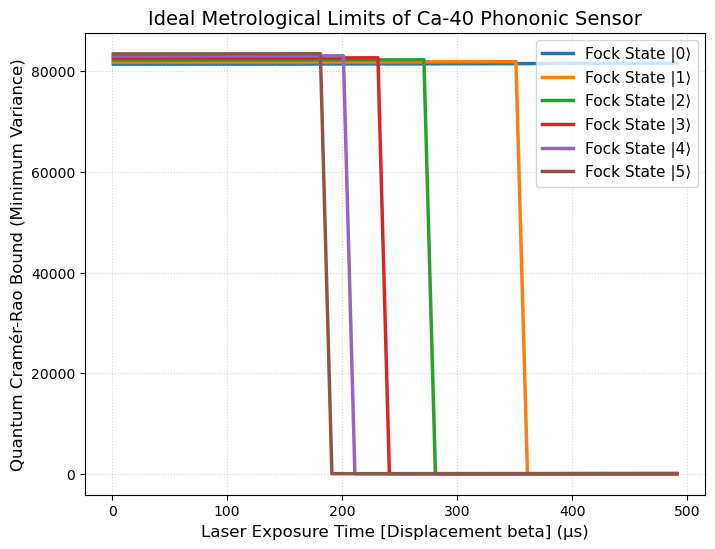

In [11]:
# Example loop to plot QCRB over time (displacement)
t_max = 500.0
dt = 1.0
time_steps = 1.0:10:t_max # Use explicit floats for the time span

states = 0:5 # Test Fock states |0> through |5>

fig = figure(figsize=(8, 6))

# Safely pre-allocate a 2D matrix of zeros
# Rows = number of Fock states, Columns = number of time steps
qcrb_matrix = zeros(Float64, length(states), length(time_steps))

for (i, n) in enumerate(states)
    qcrb_values = Float64[]
    
    # Initialize state
    ψ_mode = fockstate(mode, n)
    ψ_initial = ψ_ion ⊗ ψ_mode
    
    println("Simulating Fock State |", n, "⟩...")
    
    for (j, t) in enumerate(time_steps)
        # Run simulation to current time t
        tout1, sol1 = timeevolution.schroedinger_dynamic([0.0, t], ψ_initial, h)
        state_base = ptrace(sol1[end], 2) 
        
        # Run simulation to slightly perturbed time t + dt
        tout2, sol2 = timeevolution.schroedinger_dynamic([0.0, t + dt], ψ_initial, h)
        state_perturbed = ptrace(sol2[end], 2) 
        
        # Calculate QCRB
        qfi, qcrb = calculate_qcrb(state_base, state_perturbed, dt)
        push!(qcrb_values, qcrb)
        
        # Save to matrix using the safe integer indices (i, j)
        qcrb_matrix[i, j] = qcrb
    end

    # Plot the line for this specific Fock state immediately
    # This ensures the legend correctly labels |0>, |1>, etc.
    PyPlot.plot(time_steps, qcrb_values, label="Fock State |$n⟩", linewidth=2.5, linestyle="-")
end

# Formatting for thesis presentation
PyPlot.xlabel("Laser Exposure Time [Displacement beta] (μs)", fontsize=12)
PyPlot.ylabel("Quantum Cramér-Rao Bound (Minimum Variance)", fontsize=12)
PyPlot.title("Ideal Metrological Limits of Ca-40 Phononic Sensor", fontsize=14)
PyPlot.legend(loc="upper right", fontsize=11)
PyPlot.grid(color="gray", alpha=0.3, linestyle=":")

display(fig)

In [12]:
angle = 0
target_alpha = 0.716
cat_state = false
initial_state = nothing

red_angle = (π - 2*angle ) /2
blue_angle = red_angle + 2 *angle

if (cat_state)
    println("Preparing cat state superposition...")
    red_angle = -angle
    blue_angle = angle
end

trap_freq = 19e5 # 1.9 MHz trap frequency
ion = Ca40([("S1/2", -1/2, "g"), ("D5/2", -5/2, "e")])
chain = LinearChain(ions=[ion], comfrequencies=(x=3e6, y=3e6, z=trap_freq), selectedmodes=(; z=[1]))

mode_z = zmodes(chain)[1] # Get the first (and only) Z-mode of the chain
mode_z.N = 10

k_vec = (x̂ + ẑ) / √2
ϵ_vec = ŷ

laser_intensity = 5e6 # Fixed intensity
B_field = 1e-13

# Pre-build a trap just to grab the transition wavelength
trap_pre = Chamber(iontrap=chain, B=B_field, Bhat=ẑ)
transition_λ = transitionwavelength(ion, ("g", "e"), trap_pre)

# ---------------------------------------------------------
# NEW: DYNAMIC TIME CALCULATION VIA WIGNER-ECKART ENGINE
# ---------------------------------------------------------
hbar = 1.0545718e-34       
amu = 1.66053906e-27       
m_Ca40 = 39.96259 * amu    
c = 2.99792458e8           

# 1. Calculate Lamb-Dicke Parameter (η) dynamically
omega_trap = 2 * π * trap_freq
z_zpf = sqrt(hbar / (2 * m_Ca40 * omega_trap))
k_total = 2 * π / transition_λ
k_z = k_total / sqrt(2)
eta = k_z * z_zpf

# 2. Hijack IonSim's internal matrix element calculator
dummy_laser = Laser(I=laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)
Bhat_tuple = (; x=0.0, y=0.0, z=1.0)

# Feed the dummy laser into the exact internal physics engine
# (Note: Unexported internal functions need the module prefix 'IonSim.')
Omega_eff_Hz = IonSim.matrixelement(ion, ("g", "e"), laser_intensity, polarization(dummy_laser), wavevector(dummy_laser), Bhat_tuple)
Omega_eff = Omega_eff_Hz * 2 * π
# 3. Solve the displacemen formula backward to find exactly how long to leave the lasers on
target_time_s = (2 * target_alpha) / (eta * Omega_eff)
target_time_us = target_time_s * 1e6
# ---------------------------------------------------------

# Now build the actual lasers and final chamber
L_red = Laser(Δ = -trap_freq, ϕ=red_angle, I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)
L_blue = Laser(Δ = trap_freq, ϕ=blue_angle, I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)

trap = Chamber(iontrap=chain, B=B_field, Bhat=ẑ, lasers=[L_red, L_blue])

mode = zmodes(trap)[1]
println(mode)

ψ_ion = normalize(ion["g"] - ion["e"])
ψ_mode = fockstate(mode, 0)
ψ_initial = ψ_ion ⊗ ψ_mode

if (initial_state != nothing)
    println("Using provided initial state...")
    ψ_initial = initial_state
end

h = hamiltonian(trap, timescale=1e-6, rwa_cutoff=Inf)

# Ensure our solver array steps exactly up to our calculated target time
tspan_array = collect(0:0.5:target_time_us)
if tspan_array[end] < target_time_us
    push!(tspan_array, target_time_us)
end

println("\n--- DYNAMIC DISPLACEMENT SETUP ---")
println("Target Magnitude (|α|) : ", target_alpha)
println("Fixed Laser Intensity  : ", laser_intensity, " W/m²")
println("True Engine Ω_eff      : ", round(Omega_eff, digits=2), " rad/s")
println("Calculated Time (t)    : ", round(target_time_us, digits=3), " μs")
println("----------------------------------\n")

println("Simulating bichromatic displacement...")
tout, sol = timeevolution.schroedinger_dynamic(tspan_array, ψ_initial, h)

final_state = sol[end]

# ---------------------------------------------------------
# VERIFICATION PRINT BLOCK
# ---------------------------------------------------------
println("\n--- VERIFYING DISPLACEMENT PARAMETERS ---")
println("Zero-Point Fluctuation (z_zpf) : ", round(z_zpf * 1e9, digits=4), " nm")
println("Z-Projected Wavevector (k_z)   : ", round(k_z, digits=2), " m⁻¹")
println("Lamb-Dicke Parameter (η)       : ", round(eta, digits=4))

# We no longer calculate geometric_factor manually. We pull Ω_eff directly from the engine!
println("Effective Rabi Freq (Ω_eff)    : ", Omega_eff, " rad/s")

# |α| = 1/2 * η * Ω_eff * t 
alpha_mag = 0.5 * eta * Omega_eff * target_time_s 

println("-----------------------------------------")
println("FINAL DISPLACEMENT MAGNITUDE (|α| = 0.5 * η * Ω_eff * t) : ", round(alpha_mag, digits=3), " (Targeted: $target_alpha)")
println("-----------------------------------------")

VibrationalMode(ν=1.9e6, axis=ẑ, N=10)

--- DYNAMIC DISPLACEMENT SETUP ---
Target Magnitude (|α|) : 0.716
Fixed Laser Intensity  : 5.0e6 W/m²
True Engine Ω_eff      : 1.28920495e6 rad/s
Calculated Time (t)    : 22.344 μs
----------------------------------

Simulating bichromatic displacement...

--- VERIFYING DISPLACEMENT PARAMETERS ---
Zero-Point Fluctuation (z_zpf) : 8.1584 nm
Z-Projected Wavevector (k_z)   : 6.09326094e6 m⁻¹
Lamb-Dicke Parameter (η)       : 0.0497
Effective Rabi Freq (Ω_eff)    : 1.2892049477930975e6 rad/s
-----------------------------------------
FINAL DISPLACEMENT MAGNITUDE (|α| = 0.5 * η * Ω_eff * t) : 0.716 (Targeted: 0.716)
-----------------------------------------


Simulating Fock State |0⟩...
Simulating Fock State |1⟩...
Simulating Fock State |2⟩...
Simulating Fock State |3⟩...
Simulating Fock State |4⟩...
Simulating Fock State |5⟩...


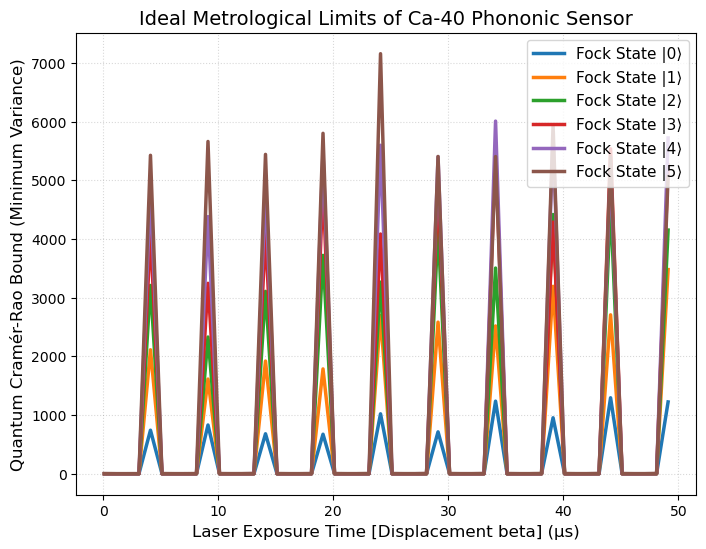

In [13]:
# Example loop to plot QCRB over time (displacement)
t_max = 50.0
dt = 1.0
time_steps = 0.1:1.0:t_max # Use explicit floats for the time span

states = 0:5 # Test Fock states |0> through |5>

fig = figure(figsize=(8, 6))

# Safely pre-allocate a 2D matrix of zeros
# Rows = number of Fock states, Columns = number of time steps
qcrb_matrix = zeros(Float64, length(states), length(time_steps))

for (i, n) in enumerate(states)
    qcrb_values = Float64[]
    
    # Initialize state
    ψ_mode = fockstate(mode, n)
    ψ_initial = ψ_ion ⊗ ψ_mode
    
    println("Simulating Fock State |", n, "⟩...")
    
    for (j, t) in enumerate(time_steps)
        # Run simulation to current time t
        tout1, sol1 = timeevolution.schroedinger_dynamic([0.0, t], ψ_initial, h)
        state_base = ptrace(sol1[end], 2) 
        
        # Run simulation to slightly perturbed time t + dt
        tout2, sol2 = timeevolution.schroedinger_dynamic([0.0, t + dt], ψ_initial, h)
        state_perturbed = ptrace(sol2[end], 2) 
        
        # Calculate QCRB
        qfi, qcrb = calculate_qcrb(state_base, state_perturbed, dt)
        push!(qcrb_values, qcrb)
        
        # Save to matrix using the safe integer indices (i, j)
        qcrb_matrix[i, j] = qcrb
    end

    # Plot the line for this specific Fock state immediately
    # This ensures the legend correctly labels |0>, |1>, etc.
    PyPlot.plot(time_steps, qcrb_values, label="Fock State |$n⟩", linewidth=2.5, linestyle="-")
end

# Formatting for thesis presentation
PyPlot.xlabel("Laser Exposure Time [Displacement beta] (μs)", fontsize=12)
PyPlot.ylabel("Quantum Cramér-Rao Bound (Minimum Variance)", fontsize=12)
PyPlot.title("Ideal Metrological Limits of Ca-40 Phononic Sensor", fontsize=14)
PyPlot.legend(loc="upper right", fontsize=11)
PyPlot.grid(color="gray", alpha=0.3, linestyle=":")

display(fig)

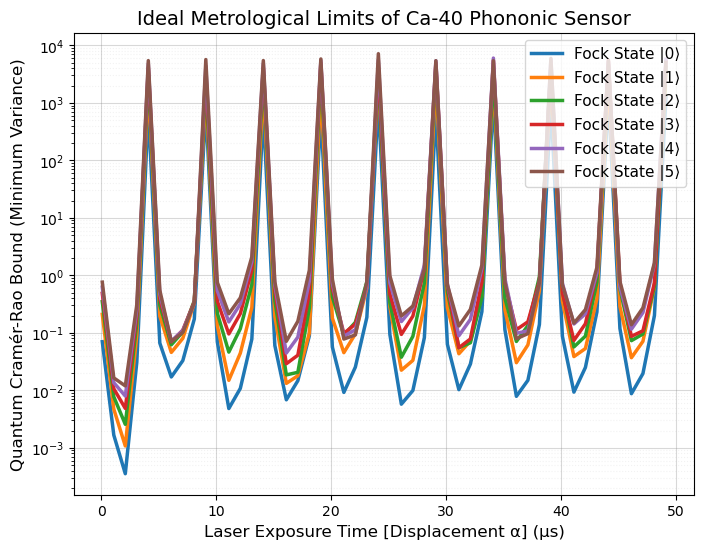

In [14]:
PyPlot.yscale("log")

# Optional: Force the Y-axis limits if you want to strictly control the window
# PyPlot.ylim(1e-2, 1e4) 

PyPlot.xlabel("Laser Exposure Time [Displacement α] (μs)", fontsize=12)
PyPlot.ylabel("Quantum Cramér-Rao Bound (Minimum Variance)", fontsize=12)
PyPlot.title("Ideal Metrological Limits of Ca-40 Phononic Sensor", fontsize=14)

PyPlot.legend(loc="upper right", fontsize=11)

# On a log scale, it often looks much better to add minor grid lines as well
PyPlot.grid(which="major", color="gray", alpha=0.3, linestyle="-")
PyPlot.grid(which="minor", color="gray", alpha=0.1, linestyle=":")

display(fig)

Simulating Fock State |0⟩...
Simulating Fock State |1⟩...
Simulating Fock State |2⟩...
Simulating Fock State |3⟩...
Simulating Fock State |4⟩...
Simulating Fock State |5⟩...


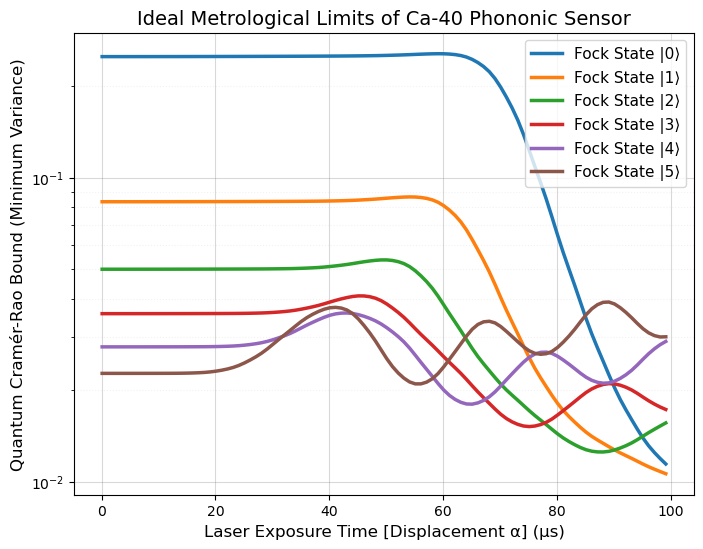

In [15]:
# ---------------------------------------------------------
# Corrected QCRB Simulation Loop
# ---------------------------------------------------------
t_max = 100.0
time_steps = 0.1:1.0:t_max 
states = 0:5 

# 1. Define the microscopic signal for the finite difference derivative
d_alpha = 1e-6 

fig = figure(figsize=(8, 6))
qcrb_matrix = zeros(Float64, length(states), length(time_steps))

for (i, n) in enumerate(states)
    qcrb_values = Float64[]
    
    ψ_mode = fockstate(mode, n)
    ψ_initial = ψ_ion ⊗ ψ_mode
    
    println("Simulating Fock State |", n, "⟩...")
    
    for (j, t) in enumerate(time_steps)
        # Step A: Build the sensor by running the laser to time t
        tout, sol = timeevolution.schroedinger_dynamic([0.0, t], ψ_initial, h)
        final_system_state = sol[end]
        
        # Step B: Extract the MOTION (Trace out Subsystem 1: Spin)
        state_base = ptrace(final_system_state, 1) 
        
        # Step C: Apply the external physical signal (d_alpha)
        # We mathematically displace the density matrix: ρ_new = D * ρ * D^†
        sim_mode = zmodes(trap)[1]
        D_signal = IonSim.displace(sim_mode, d_alpha)
        
        # Matrix multiplication applies the unitary signal to the state
        state_perturbed = D_signal * state_base * D_signal' 
        
        # Step D: Calculate true Displacement QCRB
        qfi, qcrb = calculate_qcrb(state_base, state_perturbed, d_alpha)
        push!(qcrb_values, qcrb)
        
        qcrb_matrix[i, j] = qcrb
    end

    PyPlot.plot(time_steps, qcrb_values, label="Fock State |$n⟩", linewidth=2.5, linestyle="-")
end

# Formatting
PyPlot.yscale("log")
PyPlot.xlabel("Laser Exposure Time [Displacement α] (μs)", fontsize=12)
PyPlot.ylabel("Quantum Cramér-Rao Bound (Minimum Variance)", fontsize=12)
PyPlot.title("Ideal Metrological Limits of Ca-40 Phononic Sensor", fontsize=14)
PyPlot.legend(loc="upper right", fontsize=11)
PyPlot.grid(which="major", color="gray", alpha=0.3, linestyle="-")
PyPlot.grid(which="minor", color="gray", alpha=0.1, linestyle=":")

display(fig)

Simulating Fock State |0⟩ (Ancilla Readout)...
Simulating Fock State |1⟩ (Ancilla Readout)...
Simulating Fock State |2⟩ (Ancilla Readout)...
Simulating Fock State |3⟩ (Ancilla Readout)...
Simulating Fock State |4⟩ (Ancilla Readout)...
Simulating Fock State |5⟩ (Ancilla Readout)...


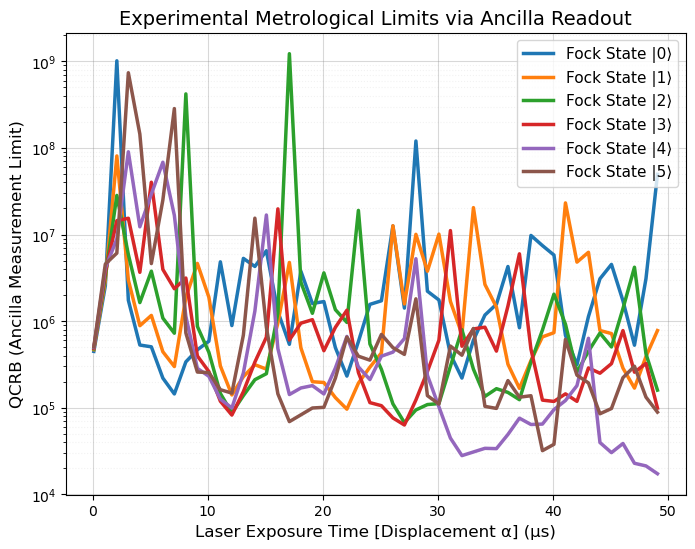

In [16]:
# ---------------------------------------------------------
# QCRB Simulation Loop: Ancilla Qubit Readout (Corrected)
# ---------------------------------------------------------
t_max = 50.0
time_steps = 0.1:1.0:t_max 
states = 0:5 

# Infinitesimal mathematical signal
d_alpha = 1e-6 

fig = figure(figsize=(8, 6))
qcrb_matrix = zeros(Float64, length(states), length(time_steps))

# Pre-build the signal operator once to save loop time
sim_mode = zmodes(trap)[1]
D_signal = IonSim.displace(sim_mode, d_alpha)
I_spin = identityoperator(ion["g"].basis)
D_system = I_spin ⊗ D_signal

for (i, n) in enumerate(states)
    qcrb_values = Float64[]
    
    ψ_mode = fockstate(mode, n)
    ψ_initial = ψ_ion ⊗ ψ_mode
    
    # APPLY SIGNAL FIRST: Create the perturbed initial state
    ψ_initial_perturbed = D_system * ψ_initial
    
    println("Simulating Fock State |", n, "⟩ (Ancilla Readout)...")
    
    for (j, t) in enumerate(time_steps)
        # 1. Base Trajectory (No Signal)
        tout1, sol1 = timeevolution.schroedinger_dynamic([0.0, t], ψ_initial, h)
        ancilla_base = ptrace(sol1[end], 2) 
        
        # 2. Perturbed Trajectory (Signal happened before SDF readout)
        tout2, sol2 = timeevolution.schroedinger_dynamic([0.0, t], ψ_initial_perturbed, h)
        ancilla_perturbed = ptrace(sol2[end], 2)
        
        # 3. Calculate true Ancilla QCRB
        qfi, qcrb = calculate_qcrb(ancilla_base, ancilla_perturbed, d_alpha)
        push!(qcrb_values, qcrb)
        
        qcrb_matrix[i, j] = qcrb
    end

    PyPlot.plot(time_steps, qcrb_values, label="Fock State |$n⟩", linewidth=2.5, linestyle="-")
end

PyPlot.yscale("log")
# We can now confidently constrain the Y-axis to relevant physical limits

PyPlot.xlabel("Laser Exposure Time [Displacement α] (μs)", fontsize=12)
PyPlot.ylabel("QCRB (Ancilla Measurement Limit)", fontsize=12)
PyPlot.title("Experimental Metrological Limits via Ancilla Readout", fontsize=14)
PyPlot.legend(loc="upper right", fontsize=11)
PyPlot.grid(which="major", color="gray", alpha=0.3, linestyle="-")
PyPlot.grid(which="minor", color="gray", alpha=0.1, linestyle=":")

display(fig)

In [17]:
println(qcrb_matrix)

[448064.95215056895 2.566373940180906e6 1.013418962374819e9 1.7443864437010654e6 530215.735010631 505595.74006384175 220181.0790838364 144408.56688830486 338960.0340494994 466829.11471065483 586609.5725432595 4.842920557360533e6 889107.8158730882 5.309046138124395e6 4.279727308239537e6 6.502039718560523e6 1.2894640146855835e6 540135.951989603 3.7717379366816157e6 1.5989133338029585e6 1.6833487908739308e6 494132.54710470233 232317.4745429169 580675.9806748842 1.5629569248941967e6 1.7192478191357213e6 1.2569187367507607e7 1.415381612422215e6 1.2016972735430028e8 2.2183223253978956e6 1.7554443207019013e6 413384.89194621396 220433.56512912223 603687.3035996517 1.1764417141164495e6 1.5675425745709108e6 4.2770938779285e6 839035.5664439333 9.770410270642862e6 7.457070378732357e6 5.798228128016409e6 684055.0705352667 313534.8239648664 1.131527157117647e6 3.0865465355157023e6 4.523097872710493e6 1.717124993366739e6 527551.3813699649 3.094960418460896e6 4.952448405464565e7; 469116.3149009546 2.9

Simulating Fock State |0⟩ (Ancilla Readout)...
Simulating Fock State |1⟩ (Ancilla Readout)...
Simulating Fock State |2⟩ (Ancilla Readout)...
Simulating Fock State |3⟩ (Ancilla Readout)...
Simulating Fock State |4⟩ (Ancilla Readout)...
Simulating Fock State |5⟩ (Ancilla Readout)...


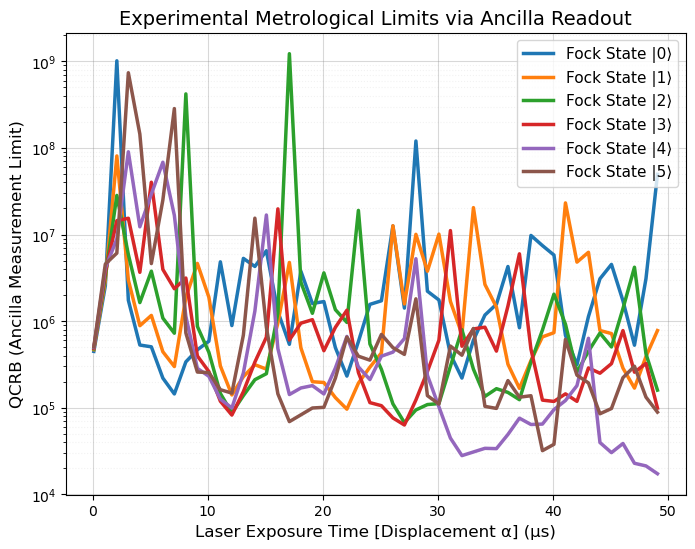

In [18]:
# ---------------------------------------------------------
# QCRB Simulation Loop: Ancilla Qubit Readout (Corrected)
# ---------------------------------------------------------
t_max = 50.0
time_steps = 0.1:1.0:t_max 
states = 0:5 

# Infinitesimal mathematical signal
d_alpha = 1e-6 

fig = figure(figsize=(8, 6))
qcrb_matrix = zeros(Float64, length(states), length(time_steps))

# Pre-build the signal operator once to save loop time
sim_mode = zmodes(trap)[1]
D_signal = IonSim.displace(sim_mode, d_alpha)
I_spin = identityoperator(ion["g"].basis)
D_system = I_spin ⊗ D_signal

for (i, n) in enumerate(states)
    qcrb_values = Float64[]
    
    ψ_mode = fockstate(mode, n)
    ψ_initial = ψ_ion ⊗ ψ_mode
    
    # APPLY SIGNAL FIRST: Create the perturbed initial state
    ψ_initial_perturbed = D_system * ψ_initial
    
    println("Simulating Fock State |", n, "⟩ (Ancilla Readout)...")
    
    for (j, t) in enumerate(time_steps)
        # 1. Base Trajectory (No Signal)
        tout1, sol1 = timeevolution.schroedinger_dynamic([0.0, t], ψ_initial, h)
        ancilla_base = ptrace(sol1[end], 2) 
        
        # 2. Perturbed Trajectory (Signal happened before SDF readout)
        tout2, sol2 = timeevolution.schroedinger_dynamic([0.0, t], ψ_initial_perturbed, h)
        ancilla_perturbed = ptrace(sol2[end], 2)
        
        # 3. Calculate true Ancilla QCRB
        qfi, qcrb = calculate_qcrb(ancilla_base, ancilla_perturbed, d_alpha)
        push!(qcrb_values, qcrb)
        
        qcrb_matrix[i, j] = qcrb
    end

    PyPlot.plot(time_steps, qcrb_values, label="Fock State |$n⟩", linewidth=2.5, linestyle="-")
end

PyPlot.yscale("log")
# We can now confidently constrain the Y-axis to relevant physical limits

PyPlot.xlabel("Laser Exposure Time [Displacement α] (μs)", fontsize=12)
PyPlot.ylabel("QCRB (Ancilla Measurement Limit)", fontsize=12)
PyPlot.title("Experimental Metrological Limits via Ancilla Readout", fontsize=14)
PyPlot.legend(loc="upper right", fontsize=11)
PyPlot.grid(which="major", color="gray", alpha=0.3, linestyle="-")
PyPlot.grid(which="minor", color="gray", alpha=0.1, linestyle=":")

display(fig)

Simulating Fock State |0⟩ (Ancilla Readout)...
Simulating Fock State |1⟩ (Ancilla Readout)...
Simulating Fock State |2⟩ (Ancilla Readout)...
Simulating Fock State |3⟩ (Ancilla Readout)...
Simulating Fock State |4⟩ (Ancilla Readout)...
Simulating Fock State |5⟩ (Ancilla Readout)...


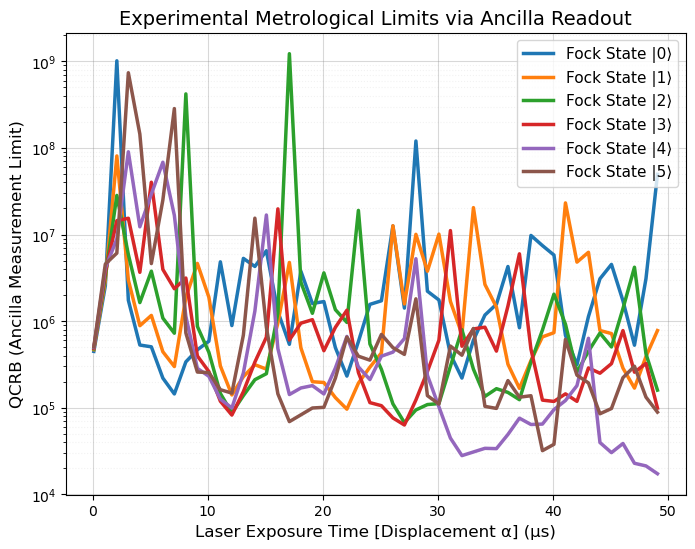

In [22]:
# ---------------------------------------------------------
# QCRB Simulation Loop: Ancilla Qubit Readout (Corrected)
# ---------------------------------------------------------
t_max = 50.0
time_steps = 0.1:1.0:t_max 
states = 0:5 
ψ_ion = normalize(ion["g"] - ion["e"])
# Infinitesimal mathematical signal
d_alpha = 1e-6 

fig = figure(figsize=(8, 6))
qcrb_matrix = zeros(Float64, length(states), length(time_steps))

# Pre-build the signal operator once to save loop time
sim_mode = zmodes(trap)[1]
D_signal = IonSim.displace(sim_mode, d_alpha)
I_spin = identityoperator(ion["g"].basis)
D_system = I_spin ⊗ D_signal

finalstate = sol[end]
finalstate_perturbed = sol[end]

for (i, n) in enumerate(states)
    qcrb_values = Float64[]
    
    ψ_mode = fockstate(mode, n)
    ψ_initial = ψ_ion ⊗ ψ_mode
    
    # APPLY SIGNAL FIRST: Create the perturbed initial state
    ψ_initial_perturbed = D_system * ψ_initial
    
    println("Simulating Fock State |", n, "⟩ (Ancilla Readout)...")
    
    for (j, t) in enumerate(time_steps)
        # 1. Base Trajectory (No Signal)
        tout1, sol1 = timeevolution.schroedinger_dynamic([0.0, t], ψ_initial, h)
        ancilla_base = ptrace(sol1[end], 2) 

        finalstate = sol1[end]
        
        # 2. Perturbed Trajectory (Signal happened before SDF readout)
        tout2, sol2 = timeevolution.schroedinger_dynamic([0.0, t], ψ_initial_perturbed, h)
        ancilla_perturbed = ptrace(sol2[end], 2)

        finalstate_perturbed = sol2[end]
        
        # 3. Calculate true Ancilla QCRB
        qfi, qcrb = calculate_qcrb(ancilla_base, ancilla_perturbed, d_alpha)
        push!(qcrb_values, qcrb)
        
        qcrb_matrix[i, j] = qcrb
    end

    PyPlot.plot(time_steps, qcrb_values, label="Fock State |$n⟩", linewidth=2.5, linestyle="-")
end

PyPlot.yscale("log")
# We can now confidently constrain the Y-axis to relevant physical limits

PyPlot.xlabel("Laser Exposure Time [Displacement α] (μs)", fontsize=12)
PyPlot.ylabel("QCRB (Ancilla Measurement Limit)", fontsize=12)
PyPlot.title("Experimental Metrological Limits via Ancilla Readout", fontsize=14)
PyPlot.legend(loc="upper right", fontsize=11)
PyPlot.grid(which="major", color="gray", alpha=0.3, linestyle="-")
PyPlot.grid(which="minor", color="gray", alpha=0.1, linestyle=":")

display(fig)

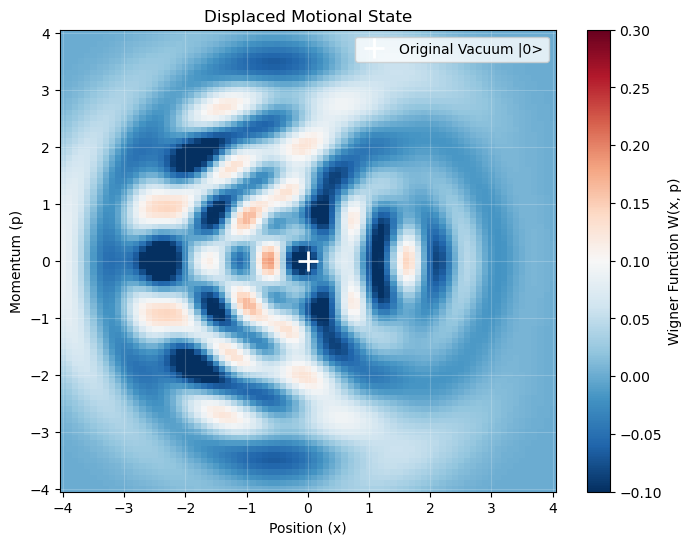

In [23]:
plot_wigner(finalstate)

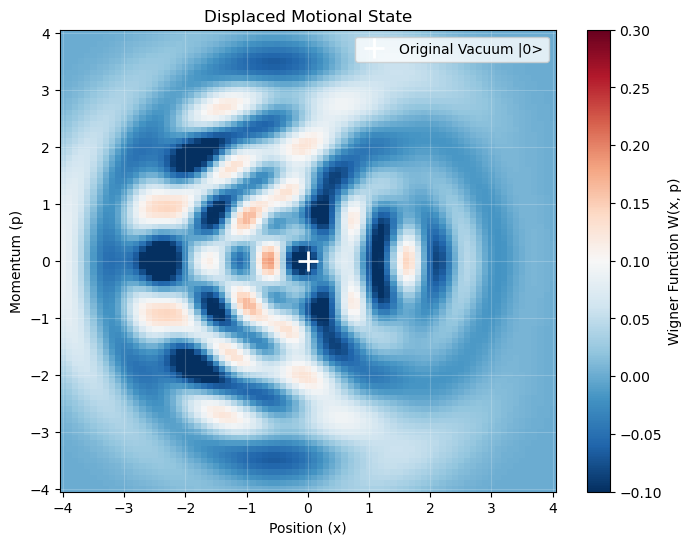

In [24]:
plot_wigner(finalstate_perturbed)

In [21]:
angle = pi /2
target_alpha = 0.2
cat_state = true
initial_state = nothing

red_angle = (π - 2*angle ) /2
blue_angle = red_angle + 2 *angle

if (cat_state)
    println("Preparing cat state superposition...")
    red_angle = -angle
    blue_angle = angle
end

trap_freq = 19e5 # 1.9 MHz trap frequency
ion = Ca40([("S1/2", -1/2, "g"), ("D5/2", -5/2, "e")])
chain = LinearChain(ions=[ion], comfrequencies=(x=3e6, y=3e6, z=trap_freq), selectedmodes=(; z=[1]))

mode_z = zmodes(chain)[1] # Get the first (and only) Z-mode of the chain
mode_z.N = 10

k_vec = (x̂ + ẑ) / √2
ϵ_vec = ŷ

laser_intensity = 5e6 # Fixed intensity
B_field = 1e-13

# Pre-build a trap just to grab the transition wavelength
trap_pre = Chamber(iontrap=chain, B=B_field, Bhat=ẑ)
transition_λ = transitionwavelength(ion, ("g", "e"), trap_pre)

# ---------------------------------------------------------
# NEW: DYNAMIC TIME CALCULATION VIA WIGNER-ECKART ENGINE
# ---------------------------------------------------------
hbar = 1.0545718e-34       
amu = 1.66053906e-27       
m_Ca40 = 39.96259 * amu    
c = 2.99792458e8           

# 1. Calculate Lamb-Dicke Parameter (η) dynamically
omega_trap = 2 * π * trap_freq
z_zpf = sqrt(hbar / (2 * m_Ca40 * omega_trap))
k_total = 2 * π / transition_λ
k_z = k_total / sqrt(2)
eta = k_z * z_zpf

# 2. Hijack IonSim's internal matrix element calculator
dummy_laser = Laser(I=laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)
Bhat_tuple = (; x=0.0, y=0.0, z=1.0)

# Feed the dummy laser into the exact internal physics engine
# (Note: Unexported internal functions need the module prefix 'IonSim.')
Omega_eff_Hz = IonSim.matrixelement(ion, ("g", "e"), laser_intensity, polarization(dummy_laser), wavevector(dummy_laser), Bhat_tuple)
Omega_eff = Omega_eff_Hz * 2 * π
# 3. Solve the displacemen formula backward to find exactly how long to leave the lasers on
target_time_s = (2 * target_alpha) / (eta * Omega_eff)
target_time_us = target_time_s * 1e6
# ---------------------------------------------------------

# Now build the actual lasers and final chamber
L_red = Laser(Δ = -trap_freq, ϕ=red_angle, I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)
L_blue = Laser(Δ = trap_freq, ϕ=blue_angle, I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)

trap = Chamber(iontrap=chain, B=B_field, Bhat=ẑ, lasers=[L_red, L_blue])

mode = zmodes(trap)[1]
println(mode)

ψ_ion = normalize(ion["g"] - ion["e"])
ψ_mode = fockstate(mode, 0)
ψ_initial = ψ_ion ⊗ ψ_mode

if (initial_state != nothing)
    println("Using provided initial state...")
    ψ_initial = initial_state
end

halpha = hamiltonian(trap, timescale=1e-6, rwa_cutoff=Inf)

# Ensure our solver array steps exactly up to our calculated target time
tspan_array = collect(0:0.5:target_time_us)
if tspan_array[end] < target_time_us
    push!(tspan_array, target_time_us)
end

println("\n--- DYNAMIC DISPLACEMENT SETUP ---")
println("Target Magnitude (|α|) : ", target_alpha)
println("Fixed Laser Intensity  : ", laser_intensity, " W/m²")
println("True Engine Ω_eff      : ", round(Omega_eff, digits=2), " rad/s")
println("Calculated Time (t)    : ", round(target_time_us, digits=3), " μs")
println("----------------------------------\n")

println("Simulating bichromatic displacement...")
tout, sol = timeevolution.schroedinger_dynamic(tspan_array, ψ_initial, h)

final_state = sol[end]

# ---------------------------------------------------------
# VERIFICATION PRINT BLOCK
# ---------------------------------------------------------
println("\n--- VERIFYING DISPLACEMENT PARAMETERS ---")
println("Zero-Point Fluctuation (z_zpf) : ", round(z_zpf * 1e9, digits=4), " nm")
println("Z-Projected Wavevector (k_z)   : ", round(k_z, digits=2), " m⁻¹")
println("Lamb-Dicke Parameter (η)       : ", round(eta, digits=4))

# We no longer calculate geometric_factor manually. We pull Ω_eff directly from the engine!
println("Effective Rabi Freq (Ω_eff)    : ", Omega_eff, " rad/s")

# |α| = 1/2 * η * Ω_eff * t 
alpha_mag = 0.5 * eta * Omega_eff * target_time_s 

println("-----------------------------------------")
println("FINAL DISPLACEMENT MAGNITUDE (|α| = 0.5 * η * Ω_eff * t) : ", round(alpha_mag, digits=3), " (Targeted: $target_alpha)")
println("-----------------------------------------")

Preparing cat state superposition...
VibrationalMode(ν=1.9e6, axis=ẑ, N=10)

--- DYNAMIC DISPLACEMENT SETUP ---
Target Magnitude (|α|) : 0.2
Fixed Laser Intensity  : 5.0e6 W/m²
True Engine Ω_eff      : 1.28920495e6 rad/s
Calculated Time (t)    : 6.241 μs
----------------------------------

Simulating bichromatic displacement...

--- VERIFYING DISPLACEMENT PARAMETERS ---
Zero-Point Fluctuation (z_zpf) : 8.1584 nm
Z-Projected Wavevector (k_z)   : 6.09326094e6 m⁻¹
Lamb-Dicke Parameter (η)       : 0.0497
Effective Rabi Freq (Ω_eff)    : 1.2892049477930975e6 rad/s
-----------------------------------------
FINAL DISPLACEMENT MAGNITUDE (|α| = 0.5 * η * Ω_eff * t) : 0.2 (Targeted: 0.2)
-----------------------------------------
